### Testing code functionality
Amy - Sep 2026

#### First create some GT spectra

In [1]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
root=Path.cwd().resolve(); root=root if (root/'create_grid.py').exists() else root.parent; sys.path.insert(0,str(root))
from create_grid import *
from optimiser_alpha_gamma import *
from metrics import voxelwise_spectrum_mae

rng=np.random.default_rng(40)

In [2]:
def show_canonical_spectra(items):
    fig, axes = plt.subplots(len(items), K, figsize=(3*K, 3*len(items)), squeeze=False)
    for row, (title, C) in enumerate(items):
        for k in range(K):
            axes[row, k].imshow(C[:, k].reshape(len(D_vals), len(T2_vals)), origin='lower', aspect='auto',
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()])
            axes[row, k].set_title(f'{title}, component {k+1}')
            axes[row, k].set_xlabel('T2'); axes[row, k].set_ylabel('D')
    plt.tight_layout()
    plt.show()


def show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=[0, 5, 12, 17]):
    fig, axes = plt.subplots(
        3, len(voxels_to_show),
        figsize=(3.2 * len(voxels_to_show), 8.5),
        constrained_layout=True,
    )

    for col, voxel in enumerate(voxels_to_show):
        for row, (name, F) in enumerate([("Ground truth", F_true), ("Estimated", F_est)]):
            image = axes[row, col].imshow(
                F[:, voxel].reshape(nD, nT2),
                origin="lower",
                aspect="auto",
                extent=[T2_vals.min(), T2_vals.max(), D_vals.min(), D_vals.max()],
            )
            axes[row, col].set_title(f"{name}: voxel {voxel}")
            axes[row, col].set_xlabel("T2 (ms)")
            axes[row, col].set_ylabel("D")
            fig.colorbar(image, ax=axes[row, col], shrink=0.75)

        # The third row reports the component weights that form this spectrum.
        components = np.arange(W_true.shape[0])
        axes[2, col].bar(components - 0.18, W_true[:, voxel], 0.36, label="Ground truth")
        axes[2, col].bar(components + 0.18, W_est[:, voxel], 0.36, label="Estimated")
        axes[2, col].set(xticks=components, xticklabels=[f"W{k + 1}" for k in components],
                         ylim=(0, 1), title=f"Weights: voxel {voxel}", ylabel="weight")
        if col == 0:
            axes[2, col].legend()

    plt.show()

def order_components(C_true, C_est, W_est, K):
    # Cost[i, j] = dissimilarity between true component i and estimated component j.
    cost = np.array([
        [np.mean((C_true[:, i] - C_est[:, j]) ** 2) for j in range(K)]
        for i in range(K)
    ])

    true_indices, estimated_indices = linear_sum_assignment(cost)

    # Put estimated components into the ground-truth component order.
    order = estimated_indices[np.argsort(true_indices)]

    C_est = C_est[:, order]
    W_est = W_est[order, :]
    return C_est, W_est

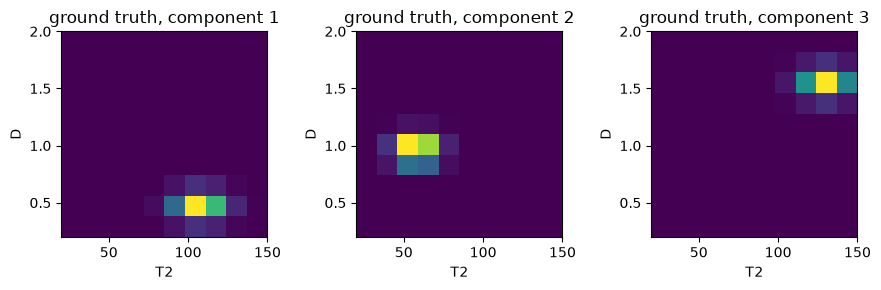

In [3]:

# Define spectra
Dmin,Dmax,nD=.2,2,10
D_vals=np.linspace(Dmin,Dmax,nD); 
T2min,T2max,nT2=20,150,10
T2_vals=np.linspace(T2min,T2max,nT2)

# Define acquisition parameters
bmin,bmax,nb=0,10,20
b_vals=np.linspace(bmin,bmax,nb)
TEmin,TEmax,nTE=10,200,20
TE_vals=np.linspace(TEmin,TEmax,nTE)

# Define fitting parameters
K=3; # Number of canonical spectra
V=12; # Number of voxels
R=8   # Rank for SVD    


# Create spectral grid
D,T2=create_DT2_grid(Dmin,Dmax,nD,T2min,T2max,nT2); 

# Create A matrix
A = create_A_matrix(D,T2,bmin,bmax,nb,TEmin,TEmax,nTE); 

# Create true C - canonical spectra
# Here have hardcoded centres
C_true=create_gaussian_compartments(D,T2,[.4,.95,1.6],[.1]*K,[110,55,135],[12,10,12])

# Define GT weights
W_true = rng.uniform(size=(K, V))
W_true /= W_true.sum(axis=0, keepdims=True)

# Set scale parameter
M0_true=np.ones(V)*300;

# Calulate the signal Y = M0 * A * C_true * W_true
SNR = 100
sigma = 1/SNR # (SNR=1000)
Y=create_signal(A,C_true,W_true,M0_true,sigma,rng)

# Create GT C_small using SVD
U,s,Vmat=apply_SVD_to_A(A,R)
C_small_true=project_C_to_C_small(C_true,s,Vmat)
#C_small_true = np.diag(s) @ V_mat.T @ C_true - should be equivalent

show_canonical_spectra([('ground truth', C_true)])


#### Run optimisation

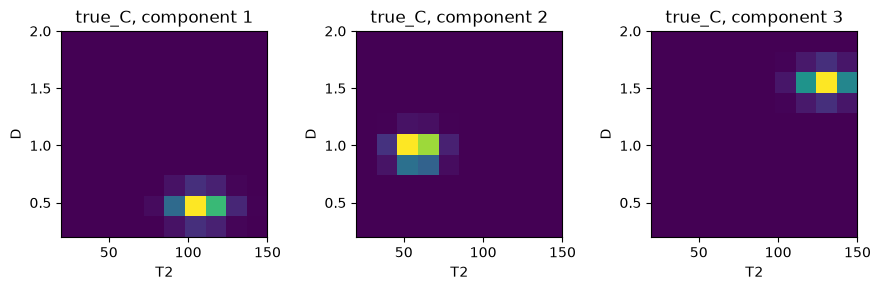

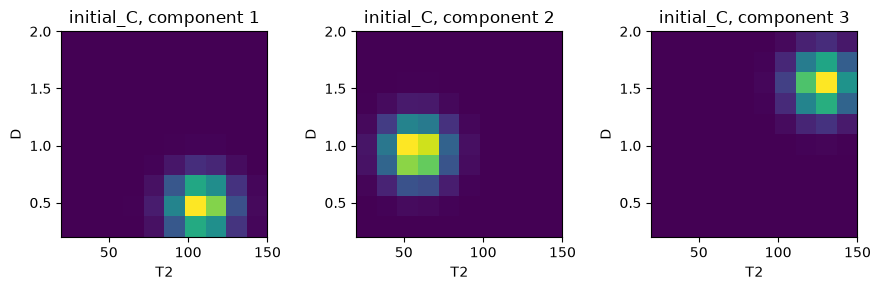

Initial M0: [289.42686586 297.86438905 297.96080605 286.06328082 294.5137834
 289.40881287 287.51809277 293.48489373 294.86052017 291.66378175
 286.04314387 285.94848438]


In [ ]:
# Set intial conditions
C0=define_initial_C_NNLS(Y,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0=project_C_to_C_small(C0,s,Vmat); 

M0_init = initialize_M0_monoexponential(Y, b_vals, TE_vals)

W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)

C0,W0=order_components(C_true, C0, W0, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
print("True M0:", M0_true)
print("Initial M0:", M0_init)



iter 0: loss=3731785.1320, fit_err=745.472978, sigma2=0.000100
iter 1: loss=2285190.3052, fit_err=455.415598, sigma2=0.000100
iter 2: loss=1657039.9495, fit_err=329.155119, sigma2=0.000100
iter 3: loss=1355517.4475, fit_err=268.344597, sigma2=0.000100
iter 4: loss=1199860.6863, fit_err=236.817931, sigma2=0.000100
iter 5: loss=1114095.2576, fit_err=219.358048, sigma2=0.000100
iter 6: loss=1063601.2589, fit_err=209.020007, sigma2=0.000100
iter 7: loss=1031783.2423, fit_err=202.467776, sigma2=0.000100
iter 8: loss=1010409.1179, fit_err=198.042130, sigma2=0.000100
iter 9: loss=995238.9738, fit_err=194.885743, sigma2=0.000100
iter 10: loss=983972.6543, fit_err=192.531836, sigma2=0.000100
iter 11: loss=975285.3679, fit_err=190.710598, sigma2=0.000100
iter 12: loss=968376.5652, fit_err=189.258395, sigma2=0.000100
iter 13: loss=962732.4463, fit_err=188.069879, sigma2=0.000100
iter 14: loss=958011.8240, fit_err=187.074883, sigma2=0.000100
iter 15: loss=953976.8685, fit_err=186.224358, sigma2=0.

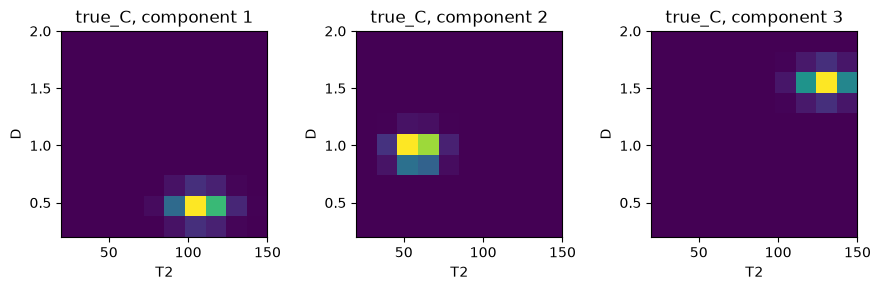

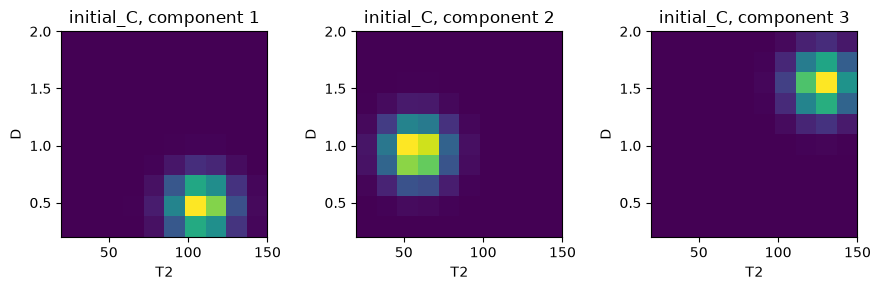

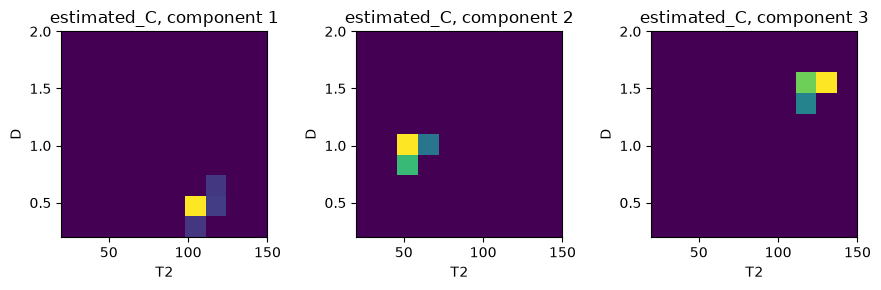

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.54583875 298.81115367 298.86023519 299.56505585 298.84896196
 299.71419133 299.74926123 298.79296751 298.9968838  299.30866133
 299.99548277 299.96925273]


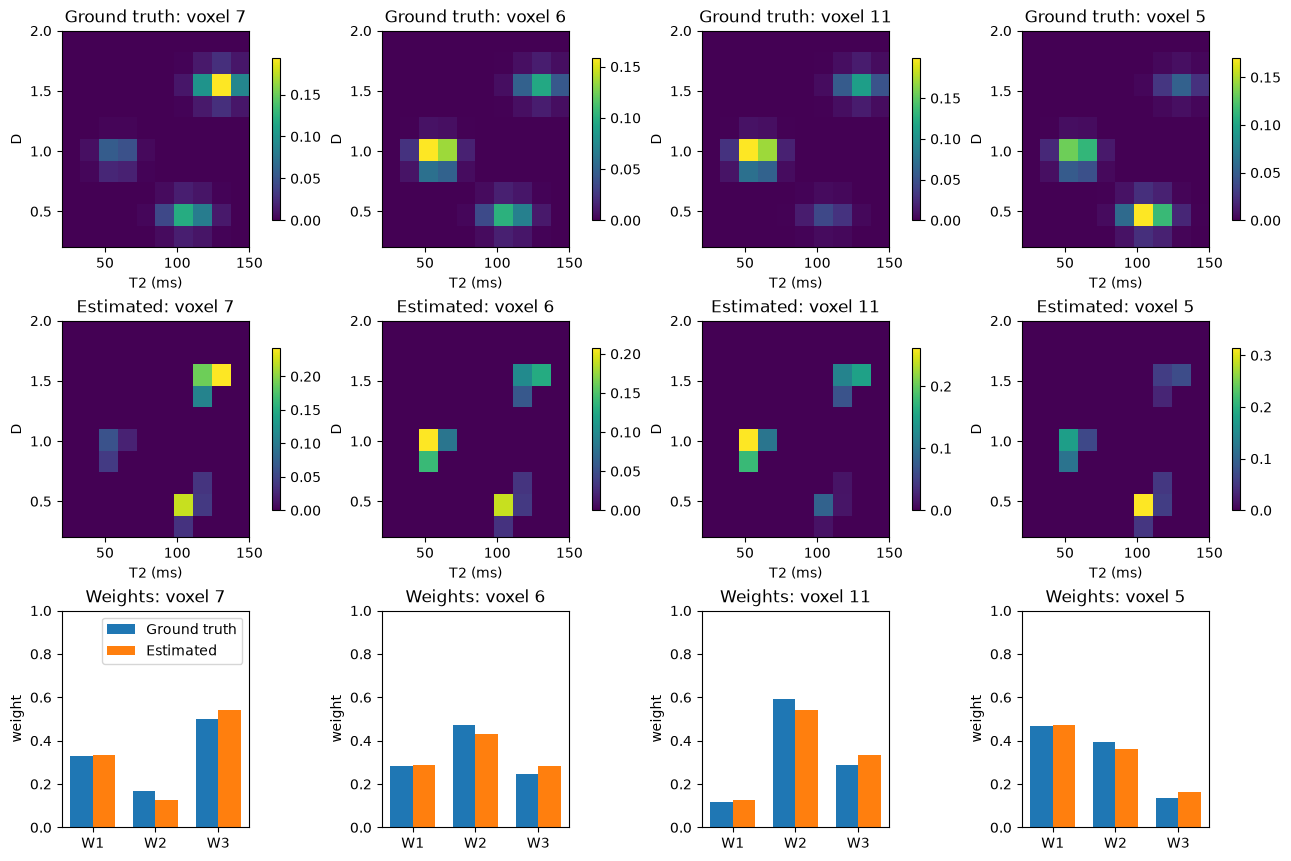

In [5]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=20,
        sigma2=sigma**2,      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first

        weight_entropy=0.0,        # do not combine with entropy here
        c_sparsity=0.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))




Note this constrained optimisation of C (not C_small) has several constraint options:

- c_smoothness
Makes each canonical D–T2 spectrum spatially smooth across neighbouring grid cells.

- c_sparsity
Encourages each canonical spectrum to concentrate its mass into fewer grid locations.

- c_diversity
Discourages different canonical spectra from overlapping at the same D–T2 locations.

Other constraints already in the model (not on C):

- C simplex constraint
Each canonical spectrum is non-negative and sums to one.

- W simplex constraint
Each voxel’s component weights are non-negative and sum to one.

- M0 > 0
Voxel signal scale cannot be negative.

- lam
Ridge/Gaussian penalty on reduced C_small; shrinks its overall magnitude. Not physical D–T2 smoothness.

- Dirichlet alpha on W
A probabilistic prior favouring globally more pure (alpha < 1) or more even (alpha > 1) voxel weights.

- weight_entropy
Non-Dirichlet alternative that encourages individual voxel weights to be sparse/dominant.

#### We can make C smoother with the smoothness option

iter 0: loss=3733995.9880, fit_err=745.914834, sigma2=0.000100
iter 1: loss=2283167.1403, fit_err=455.011309, sigma2=0.000100
iter 2: loss=1656837.2647, fit_err=329.116270, sigma2=0.000100
iter 3: loss=1355712.1689, fit_err=268.385720, sigma2=0.000100
iter 4: loss=1200088.4662, fit_err=236.865856, sigma2=0.000100
iter 5: loss=1114267.3267, fit_err=219.394884, sigma2=0.000100
iter 6: loss=1063716.8184, fit_err=209.045525, sigma2=0.000100
iter 7: loss=1031849.1236, fit_err=202.483306, sigma2=0.000100
iter 8: loss=1010432.9566, fit_err=198.049166, sigma2=0.000100
iter 9: loss=995231.2031, fit_err=194.886355, sigma2=0.000100
iter 10: loss=983938.2661, fit_err=192.527014, sigma2=0.000100
iter 11: loss=975229.8451, fit_err=190.701433, sigma2=0.000100
iter 12: loss=968305.4658, fit_err=189.246001, sigma2=0.000100
iter 13: loss=962650.3014, fit_err=188.055163, sigma2=0.000100
iter 14: loss=957922.3352, fit_err=187.058591, sigma2=0.000100
iter 15: loss=953880.2312, fit_err=186.206520, sigma2=0.

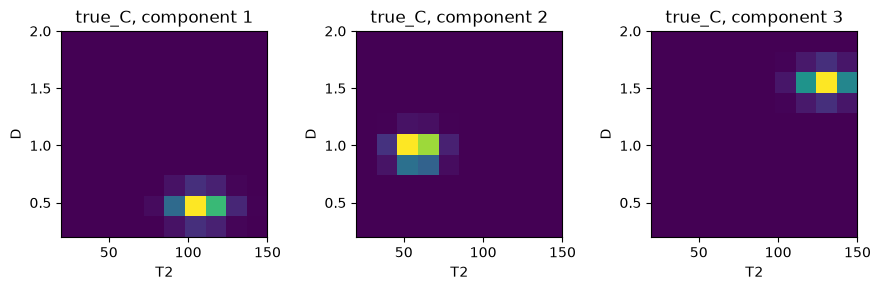

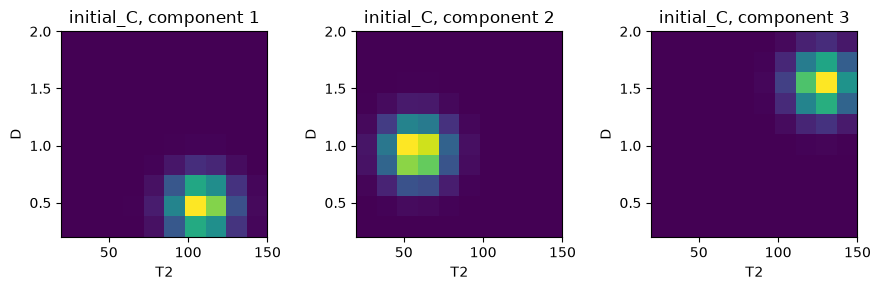

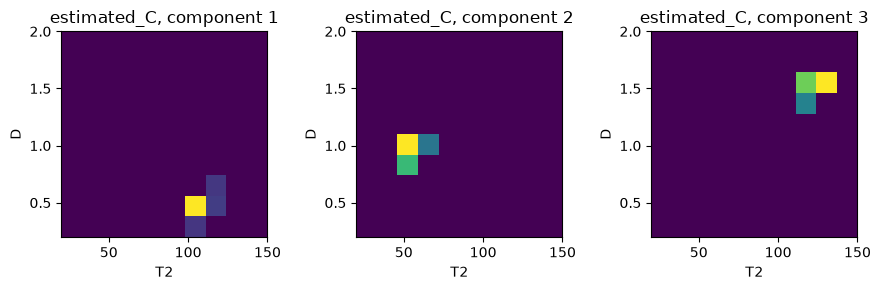

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.54343357 298.80977568 298.85875431 299.56467071 298.84883261
 299.71089546 299.74707116 298.7937814  298.99553403 299.30654332
 299.99347668 299.96740155]


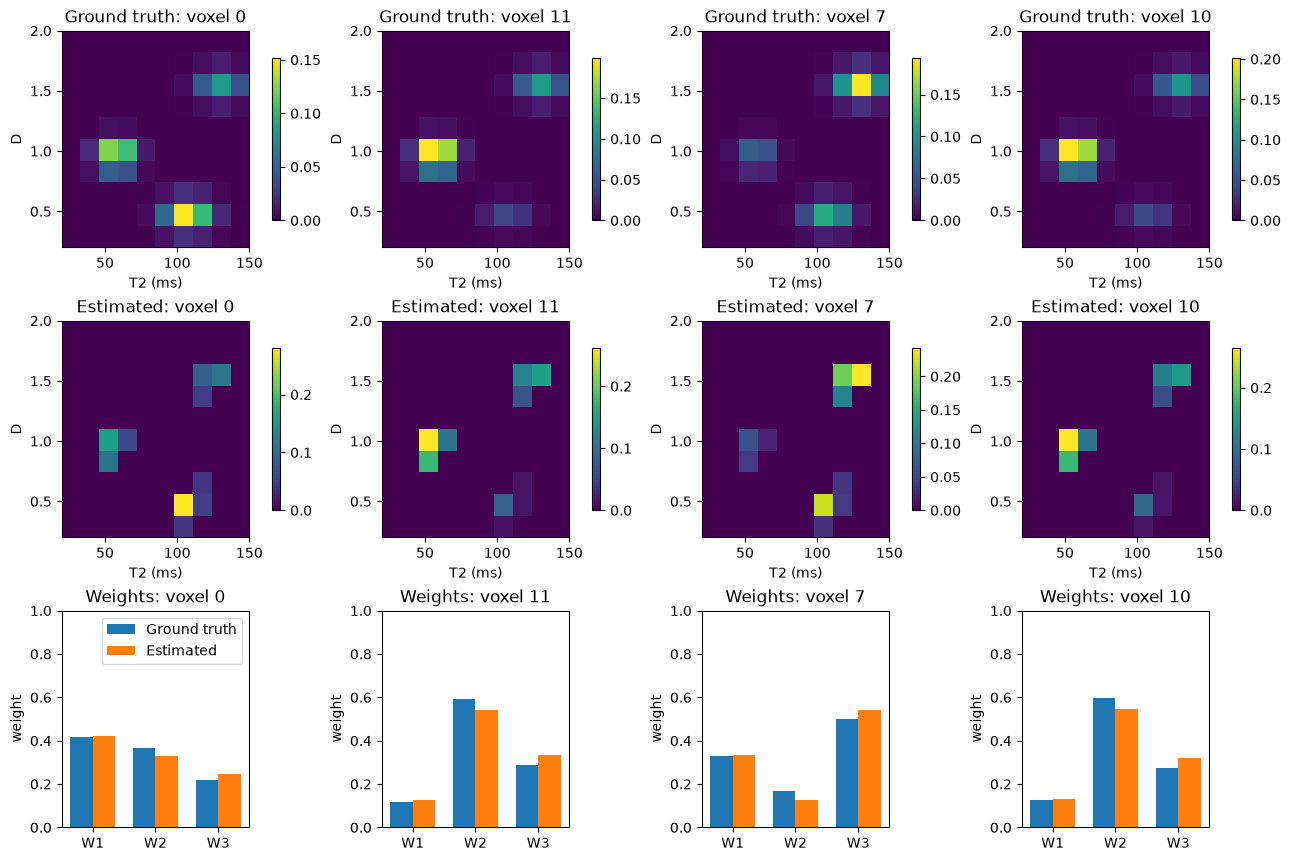

In [6]:
# This already looks excellent
# Lets estimate C and W directly

W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=20,
        sigma2=sigma**2,      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first

        weight_entropy=0.0,        # do not combine with entropy here
        c_sparsity=0.0,            # make C sparse
        c_smoothness=1.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))


#### or sparse

iter 0: loss=3736270.4315, fit_err=746.369377, sigma2=0.000100
iter 1: loss=2291371.6235, fit_err=456.648358, sigma2=0.000100
iter 2: loss=1656369.2426, fit_err=329.016530, sigma2=0.000100
iter 3: loss=1354718.5011, fit_err=268.179942, sigma2=0.000100
iter 4: loss=1199127.7180, fit_err=236.666465, sigma2=0.000100
iter 5: loss=1113442.4510, fit_err=219.222771, sigma2=0.000100
iter 6: loss=1063022.1965, fit_err=208.899705, sigma2=0.000100
iter 7: loss=1031271.7546, fit_err=202.361256, sigma2=0.000100
iter 8: loss=1009955.6470, fit_err=197.947483, sigma2=0.000100
iter 9: loss=994835.2318, fit_err=194.801322, sigma2=0.000100
iter 10: loss=983610.3220, fit_err=192.455971, sigma2=0.000100
iter 11: loss=974959.7659, fit_err=190.642343, sigma2=0.000100
iter 12: loss=968081.3980, fit_err=189.196479, sigma2=0.000100
iter 13: loss=962462.5285, fit_err=188.013247, sigma2=0.000100
iter 14: loss=957762.5861, fit_err=187.022603, sigma2=0.000100
iter 15: loss=953744.5813, fit_err=186.175665, sigma2=0.

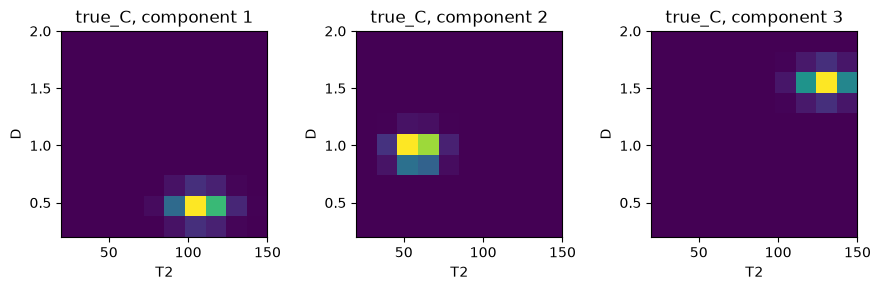

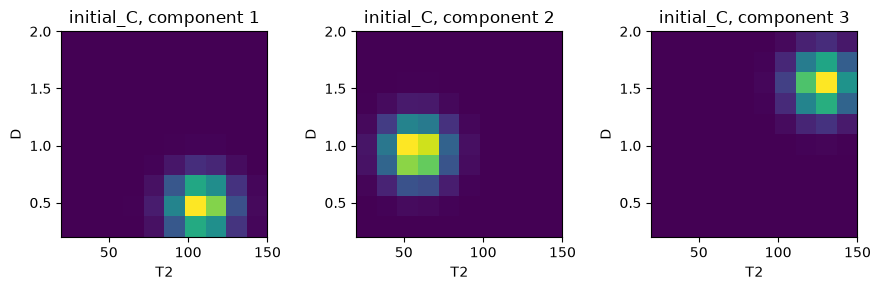

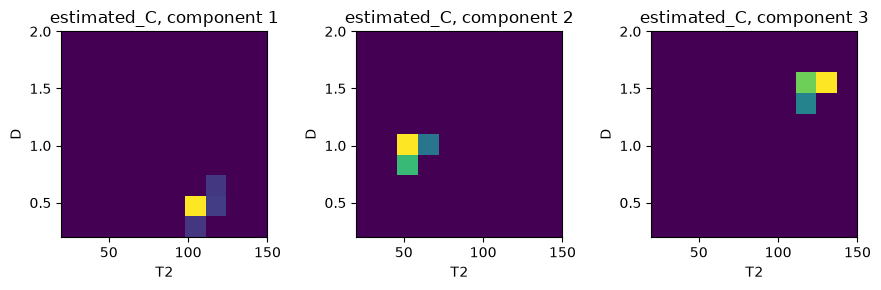

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [299.54766516 298.81110603 298.86139208 299.56519616 298.84929525
 299.71664742 299.75077214 298.79262712 298.99805959 299.31036713
 299.99662529 299.97029113]


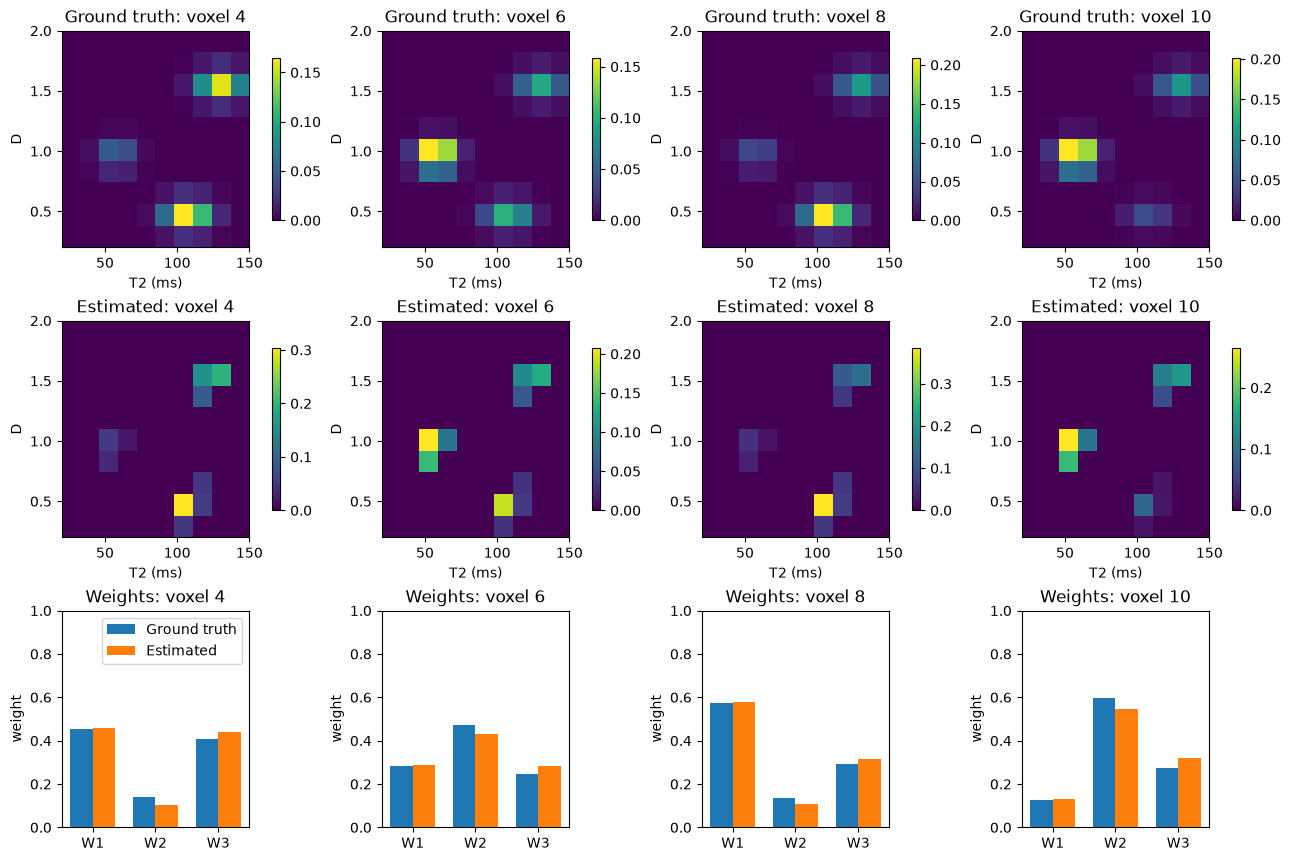

In [7]:


W_est, M0_est, C_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_constrained_optimisation(
        Y, U, s, Vmat,
        C0, M0_init,
        K=K,
        n_iter=20,
        sigma2=sigma**2,      # choose from expected noise level # DO WE NEED THIS
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,
        m0_prior_sigma=0.15,

        alpha=1.0,                  # disables Dirichlet prior
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first

        weight_entropy=0.0,        # do not combine with entropy here
        c_sparsity=1.0,            # make C sparse
        c_smoothness=0.0,          # make C smooth
        c_diversity=0.0,           # encourage diversity in C (is components not the same)
        c_maxiter=100,
        nD=nD,
        nT2=nT2,
        
        verbose_every=1,
    )
)

C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)

show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))


#### This looks pretty good
Some notes:

We have simplex constraints on C and W.
C is shared across voxels making it heirarchical
Initialisation of C, M0 and W is good, giving a very good baseline.
You can make C smoother or sparser by adding additional constraints.

You do not need a Dirichlet prior on W for this to be described as a hierarchical Bayesian MAP model.
With:
alpha = 1.0
update_alpha_flag = False
The weight prior is effectively uniform over the simplex. That is a valid weak prior and is a good baseline for basic recovery.

You can set weight_entropy>0 to make W have a sparist-favouring prior. This might be helpful for harder optimisations.

m0_prior = M0_init
m0_prior_sigma = 0.15
<-- This sets M0 to be around an initial value which is estimated using a monoexpoential fit. sigma gives the spread around the initial value


# 2. How about estimating C_small

iter 0: loss=8115355.4134, fit_err=1622.179306, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 1: loss=8068720.3470, fit_err=1612.862169, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 2: loss=8037512.0008, fit_err=1606.623956, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 3: loss=8023641.0850, fit_err=1603.851248, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 4: loss=8017226.2895, fit_err=1602.569207, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 5: loss=8014152.4227, fit_err=1601.955266, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 6: loss=8012633.7860, fit_err=1601.652417, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 7: loss=8011864.1051, fit_err=1601.499430, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 8: loss=8011465.3127, fit_err=1601.420686, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 9: loss=8011254.4164, fit_err=1601.379566, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 10: loss=8011140.3324, fit_err=1601.357842, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 11: 

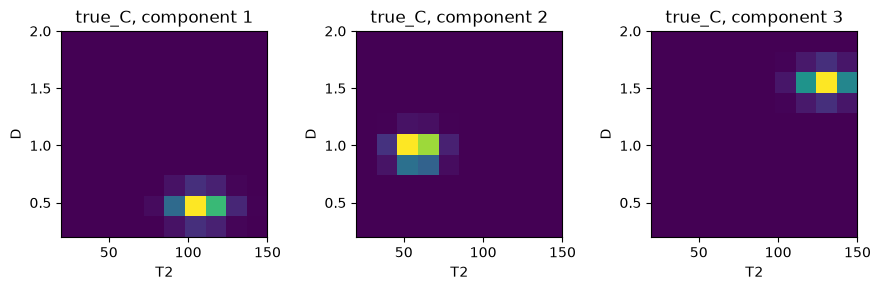

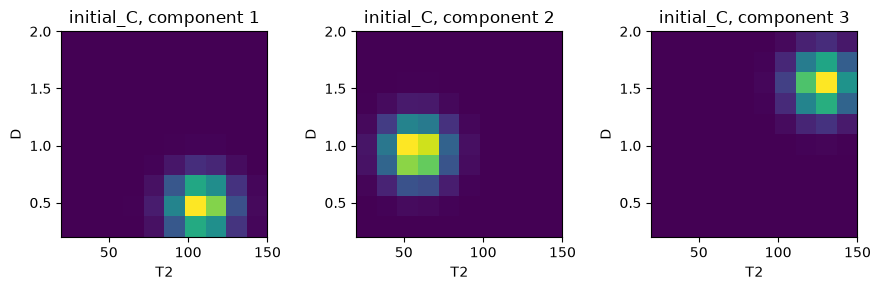

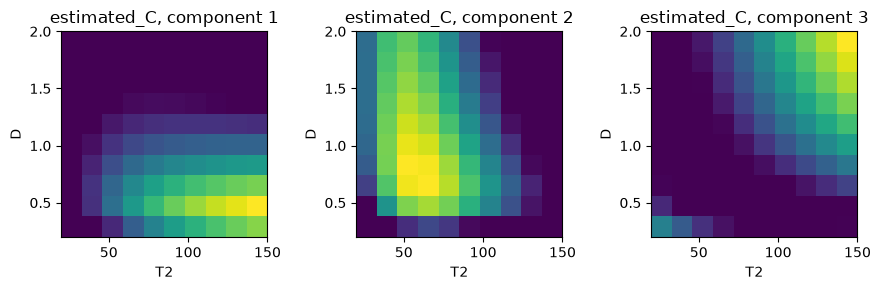

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [294.15251699 298.48300966 298.59879429 292.26209493 297.03798051
 293.83809286 292.67642552 296.54749135 297.23380131 295.60076029
 290.91799428 290.99247119]


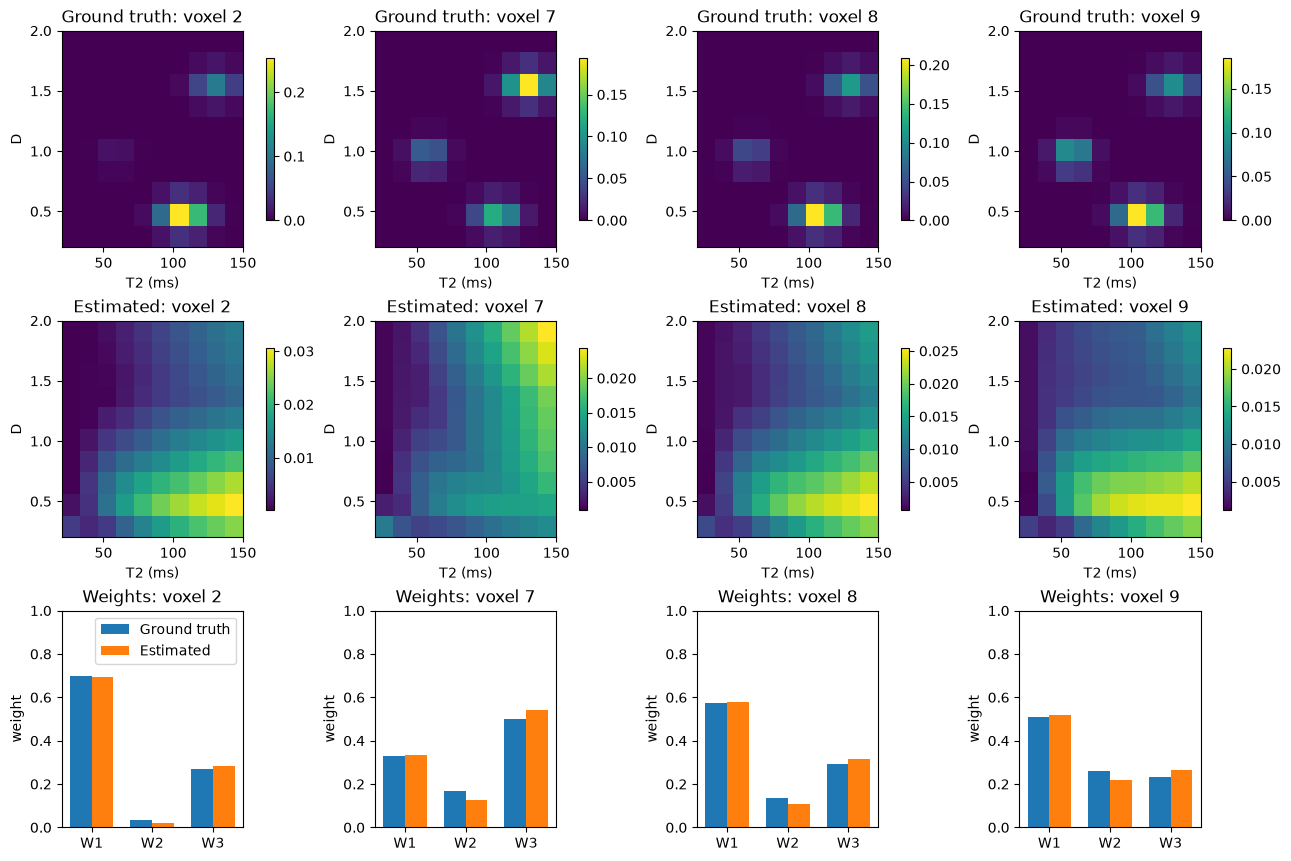

In [8]:
R = 6
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


# Here we use run_optimisation not run_optimisation_constrained 
W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=sigma**2,
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=False,
        alpha_update_start=5,      # allow C/W to settle first

        #weight_entropy=0.0,        # do not combine with entropy here
        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)

C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))




#### The spectra are a bit dodgy - can change R to adjust this, but the weights actually look quite good regardless. Could fit peaks afterwards?

#### 3. What happens if you set a Drichilet prior and try to estimate W and C_small?
Trying to recreate Maria's issues

iter 0: loss=8115355.4134, fit_err=1622.179306, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 1: loss=8068720.3470, fit_err=1612.862169, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 2: loss=8037512.0008, fit_err=1606.623956, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 3: loss=8023641.0850, fit_err=1603.851248, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 4: loss=8017226.2895, fit_err=1602.569207, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 5: loss=8014150.6316, fit_err=1601.955266, sigma2=0.000100, lam=0.0000, alpha=1.6870
iter 6: loss=8012632.0291, fit_err=1601.652419, sigma2=0.000100, lam=0.0000, alpha=1.6812
iter 7: loss=8011862.3671, fit_err=1601.499434, sigma2=0.000100, lam=0.0000, alpha=1.6770
iter 8: loss=8011463.5852, fit_err=1601.420689, sigma2=0.000100, lam=0.0000, alpha=1.6739
iter 9: loss=8011252.6949, fit_err=1601.379569, sigma2=0.000100, lam=0.0000, alpha=1.6717
iter 10: loss=8011138.6145, fit_err=1601.357844, sigma2=0.000100, lam=0.0000, alpha=1.6700
iter 11: 

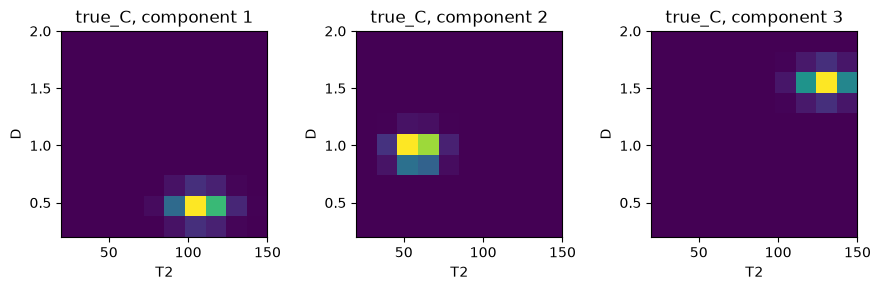

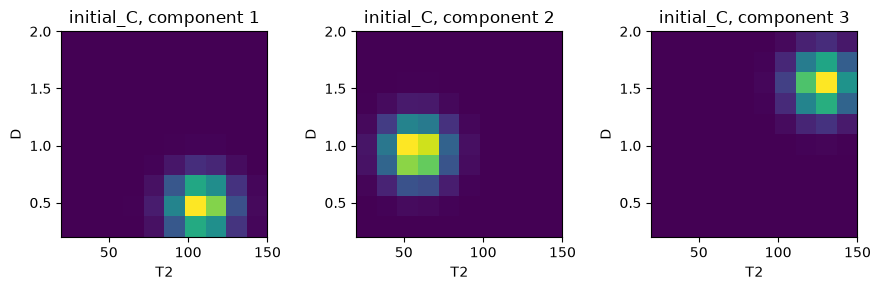

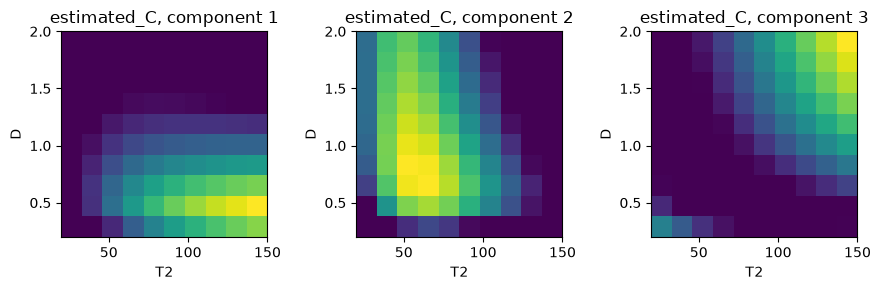

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [294.15251908 298.48302447 298.59880595 292.26209225 297.03798882
 293.83809377 292.67642394 296.54749857 297.23380982 295.60076502
 290.91798852 290.99246559]


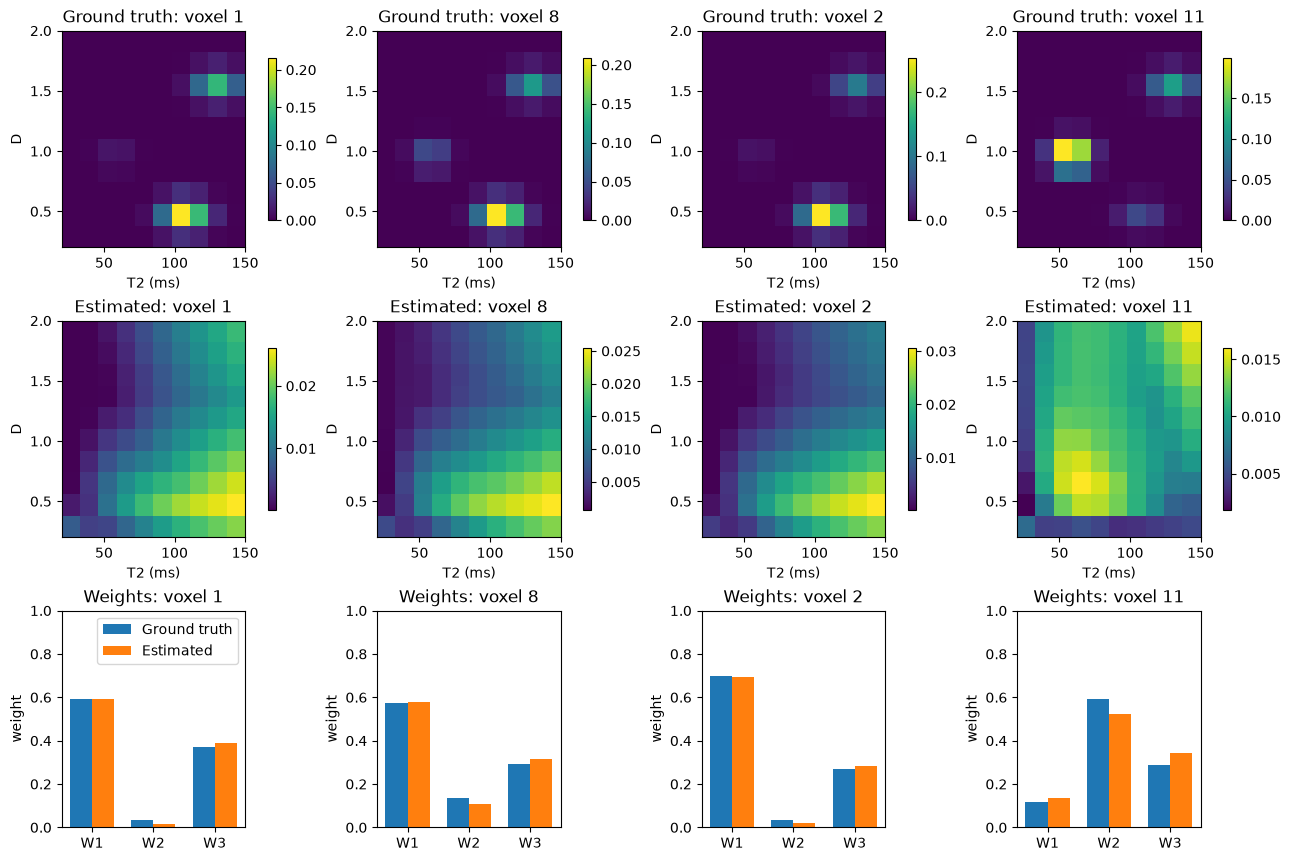

In [9]:
# 

R = 6
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0 = project_C_to_C_small(C0, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0 = initialize_W_from_C(Y, U, Csmall0, M0_init, bound_eps=1e-3)


W_est, M0_est, Csmall_est, alpha_est, sigma2_est, lam_est, losses, fit_errs = (
    run_optimisation(
        Y, U,
        Csmall0, M0_init,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=sigma**2,
        lam=1e-8,
        W=W0,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first

        #weight_entropy=0.0,        # do not combine with entropy here
        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est = estimate_C(Vmat, s, Csmall_est)
C_est, W_est = order_components(C_true, C_est, W_est, K)

F_true = C_true @ W_true
F_est = C_est @ W_est

print("W MAE:", np.mean(np.abs(W_true - W_est)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est)))
print("C MAE:", np.mean(np.abs(C_true - C_est)))
print("alpha:", alpha_est)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0)])
show_canonical_spectra([('estimated_C', C_est)])

print("True M0:", M0_true)
print("Estimated M0:", M0_est)


show_voxelwise_spectra(F_true, F_est, W_true, W_est, voxels_to_show=rng.choice(V, size=4, replace=False))




#### This also seems to work - our spectra are blurred but we recover the wieghts well and we can postprocess the spectra. 

Note, the GT fibre fractions are not drawn from a Dirichlet distribution, do there is no "GT" alpha, but this optimisation uses Dirichlet as a regulariser.

### Let's try with a GT alpha to see if we can recover this also

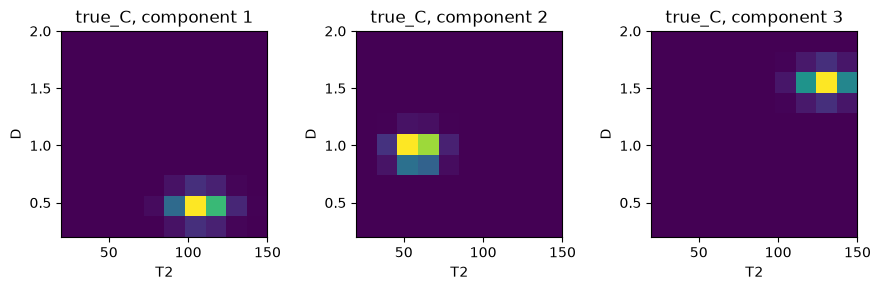

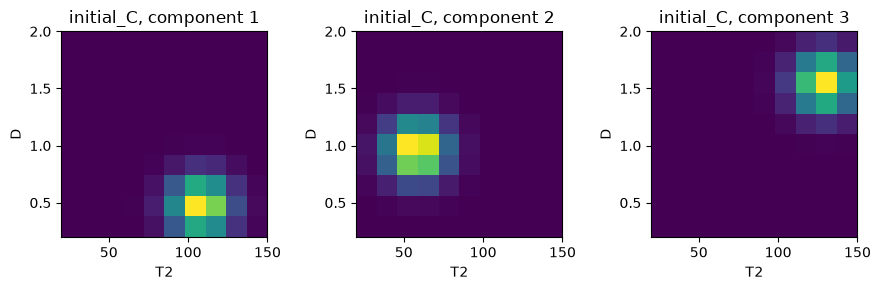

iter 0: loss=8933722.5603, fit_err=1785.626917, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 1: loss=8623551.7909, fit_err=1723.518593, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 2: loss=8492174.7660, fit_err=1697.167102, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 3: loss=8428754.1748, fit_err=1684.420666, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 4: loss=8394673.8711, fit_err=1677.555396, sigma2=0.000100, lam=0.0000, alpha=1.0000
iter 5: loss=8375459.9604, fit_err=1673.674247, sigma2=0.000100, lam=0.0000, alpha=0.8597
iter 6: loss=8364285.5171, fit_err=1671.409553, sigma2=0.000100, lam=0.0000, alpha=0.8566
iter 7: loss=8357646.3459, fit_err=1670.058688, sigma2=0.000100, lam=0.0000, alpha=0.8542
iter 8: loss=8353643.2077, fit_err=1669.240353, sigma2=0.000100, lam=0.0000, alpha=0.8524
iter 9: loss=8351204.5728, fit_err=1668.739106, sigma2=0.000100, lam=0.0000, alpha=0.8509
iter 10: loss=8349708.0831, fit_err=1668.429586, sigma2=0.000100, lam=0.0000, alpha=0.8498
iter 11: 

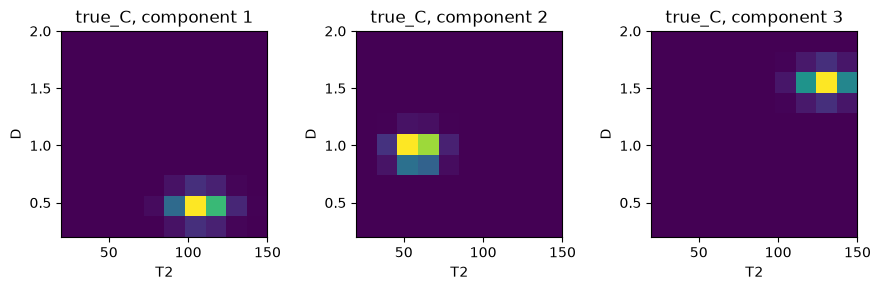

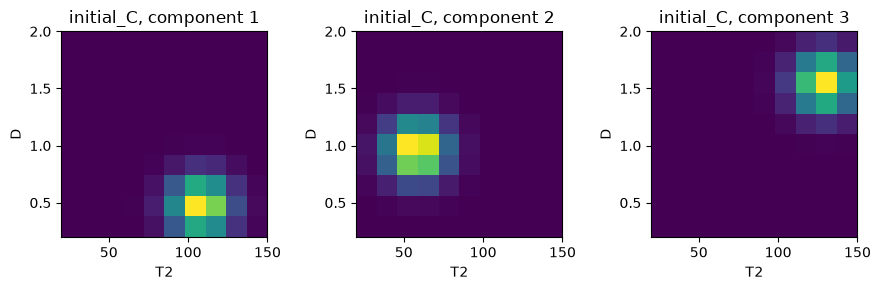

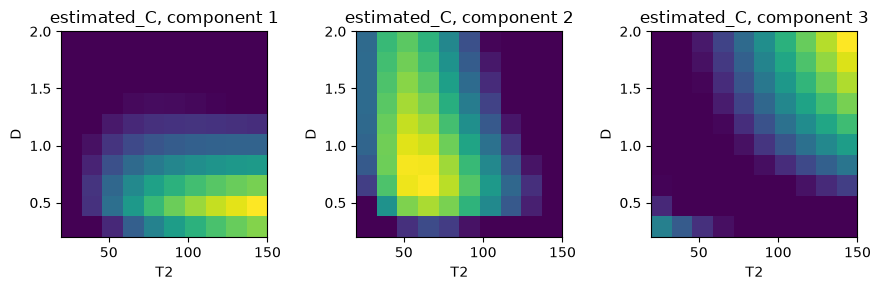

True M0: [300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300. 300.]
Estimated M0: [294.30009008 294.98420383 295.97358001 295.43432177 294.47587079
 295.79749133 295.61635378 295.77876996 296.36159737 294.76154255
 299.12712541 294.4132662 ]


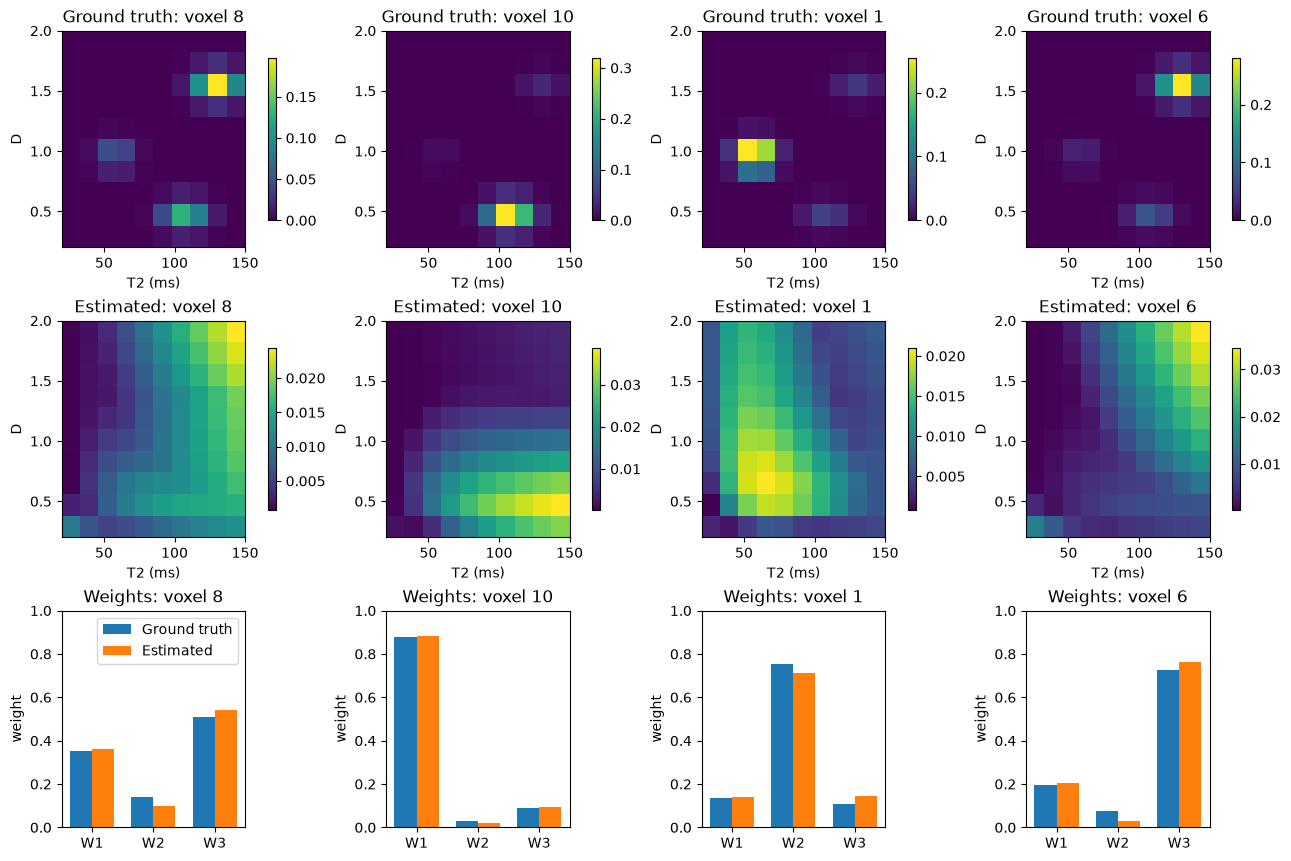

In [10]:
alpha_true = 0.5
W_true_dirichlet = rng.dirichlet(alpha_true * np.ones(K), size=V).T

# Calulate the signal Y = M0 * A * C_true * W_true
Y_dirichlet=create_signal(A,C_true,W_true_dirichlet,M0_true,sigma,rng)

# Set intial conditions
C0_dirichlet=define_initial_C_NNLS(Y_dirichlet,A,range(V),K,D_vals,T2_vals,D_vals.min(),D_vals.max(),T2_vals.min(),T2_vals.max(),nD,nT2)
#^^^ This function could be re-written to not have so many arguments 
Csmall0_dirichlet=project_C_to_C_small(C0_dirichlet,s,Vmat); 

M0_init_dirichlet = initialize_M0_monoexponential(Y_dirichlet, b_vals, TE_vals)

W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)

C0_dirichlet,W0_dirichlet=order_components(C_true, C0_dirichlet, W0_dirichlet, K)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])


# ----------------


R = 6
U, s, Vmat = apply_SVD_to_A(A, R)

# C0 stays on the physical D–T2 grid, so it does not depend on R.
Csmall0_dirichlet = project_C_to_C_small(C0_dirichlet, s, Vmat)

# Refit weights because U @ Csmall0 has changed.
W0_dirichlet = initialize_W_from_C(Y_dirichlet, U, Csmall0_dirichlet, M0_init_dirichlet, bound_eps=1e-3)


W_est_dirichlet, M0_est_dirichlet, Csmall_est_dirichlet, alpha_est_dirichlet, sigma2_est_dirichlet, lam_est_dirichlet, losses_dirichlet, fit_errs_dirichlet = (
    run_optimisation(
        Y_dirichlet, U,
        Csmall0_dirichlet, M0_init_dirichlet,
        K=K, R=R,
        eps=1e-10,
        n_iter=20,
        sigma2=sigma**2,
        lam=1e-8,
        W=W0_dirichlet,

        update_W_flag=True,
        update_C_flag=True,
        update_M0_flag=True,
        m0_prior=M0_init_dirichlet,   # set M0 prior as Gaussian around initial guess
        m0_prior_sigma=0.15,

        alpha=1.0,
        update_alpha_flag=True,
        alpha_update_start=5,      # allow C/W to settle first

        #weight_entropy=0.0,        # do not combine with entropy here
        #c_sparsity=0.0,
        #c_smoothness=0.0,
        #c_diversity=0.0,
        #c_maxiter=100,

        verbose_every=1,
    )
)


C_est_dirichlet = estimate_C(Vmat, s, Csmall_est_dirichlet)
C_est_dirichlet, W_est_dirichlet = order_components(C_true, C_est_dirichlet, W_est_dirichlet, K)

F_true = C_true @ W_true_dirichlet
F_est = C_est_dirichlet @ W_est_dirichlet

print("W MAE:", np.mean(np.abs(W_true_dirichlet - W_est_dirichlet)))
print("M0 MAE:", np.mean(np.abs(M0_true - M0_est_dirichlet)))
print("C MAE:", np.mean(np.abs(C_true - C_est_dirichlet)))
print("alpha:", alpha_est_dirichlet)

show_canonical_spectra([('true_C', C_true)])
show_canonical_spectra([('initial_C', C0_dirichlet)])
show_canonical_spectra([('estimated_C', C_est_dirichlet)])
print("True M0:", M0_true)
print("Estimated M0:", M0_est_dirichlet)


show_voxelwise_spectra(F_true, F_est, W_true_dirichlet, W_est_dirichlet, voxels_to_show=rng.choice(V, size=4, replace=False))






#### alpha isnt reconstructed perfectly but it does track with GT (e.g. estimated=0.3 when GT=0.1, and estimated = 5 when GT=10)

This also looks reasonable